# Standard Logistic Regression - Lung Cancer Dataset

This notebook trains a standard (non-private) Logistic Regression classifier on the Lung Cancer dataset (50,000 samples, 23 features, 3-class target) to establish baseline performance.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
# Load preprocessed data
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
bounds = data['bounds']
scaler = data['scaler']

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)

n_classes = data.get('n_classes', 3)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Number of classes: {n_classes}")
print(f"\nFeatures: {feature_names}")

Training data shape: (40000, 23)
Test data shape: (10000, 23)
Number of features: 23
Number of classes: 3

Features: ['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']


## 3. Train Standard Logistic Regression Model

In [3]:
# Initialize Logistic Regression Classifier (multi-class)
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    multi_class='multinomial'
)

print("Training Standard Logistic Regression...")
_t0 = time.perf_counter()
lr_model.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = lr_model.predict(X_train)
print("Training complete!")

Training Standard Logistic Regression...
Training complete!


## 4. Make Predictions

In [4]:
# Predictions on test set
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction probabilities shape: {y_pred_proba.shape}")

Predictions shape: (10000,)
Prediction probabilities shape: (10000, 3)


## 5. Model Evaluation

In [5]:
# Calculate metrics (weighted for multi-class)
extra = ExtraMetrics()
accuracy = accuracy_score(y_test, y_pred)
extra.add(y_test, y_pred, model=lr_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("=" * 60)
print("STANDARD LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f} (weighted)")
print(f"Precision: {precision:.4f} (weighted)")
print(f"Recall:    {recall:.4f} (weighted)")
print("=" * 60)

STANDARD LOGISTIC REGRESSION - PERFORMANCE METRICS
Accuracy:  1.0000
F1-Score:  1.0000 (weighted)
Precision: 1.0000 (weighted)
Recall:    1.0000 (weighted)


## 6. Confusion Matrix

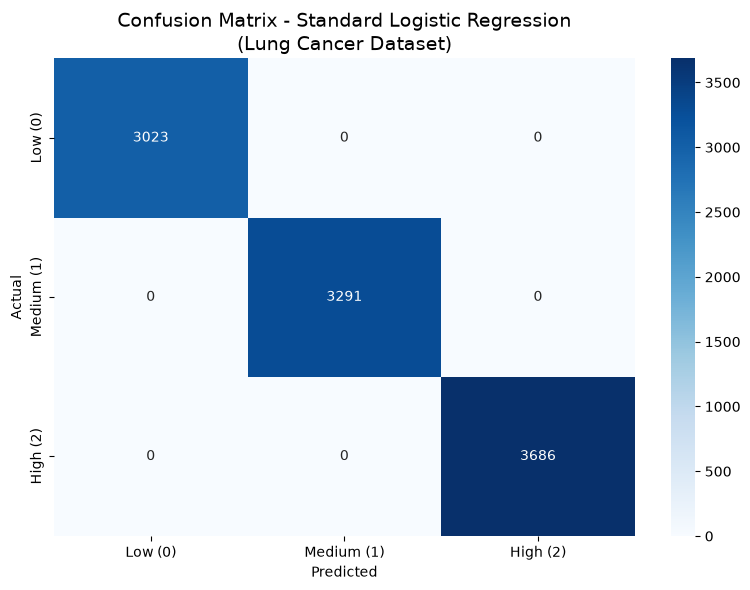

In [6]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low (0)', 'Medium (1)', 'High (2)'],
            yticklabels=['Low (0)', 'Medium (1)', 'High (2)'])
plt.title('Confusion Matrix - Standard Logistic Regression\n(Lung Cancer Dataset)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 7. Classification Report

In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Low (0)', 'Medium (1)', 'High (2)']))

Classification Report:
              precision    recall  f1-score   support

     Low (0)       1.00      1.00      1.00      3023
  Medium (1)       1.00      1.00      1.00      3291
    High (2)       1.00      1.00      1.00      3686

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## 8. Save Baseline Results

In [8]:
os.makedirs('output', exist_ok=True)

baseline_results = {
    'model': 'Standard Logistic Regression',
    'dataset': 'Lung Cancer',
    'accuracy': accuracy,
    'f1_score': f1,
    'precision': precision,
    'recall': recall
}
baseline_results.update(extra.means())

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('output/baseline_results.csv', index=False)

with open('output/std_lr_report.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)

print("Results saved to output/baseline_results.csv")
print(f"\nBaseline Accuracy:  {accuracy:.4f}")
print(f"Baseline F1-Score:  {f1:.4f}")
print(f"Baseline Precision: {precision:.4f}")
print(f"Baseline Recall:    {recall:.4f}")

# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model
export_model(lr_model, 'output/model/std_lr_model.pkl')


print("Added metrics:")
print(extra.describe())

Results saved to output/baseline_results.csv

Baseline Accuracy:  1.0000
Baseline F1-Score:  1.0000
Baseline Precision: 1.0000
Baseline Recall:    1.0000


Model successfully exported to output/model/std_lr_model.pkl
Added metrics:
  Train Acc:      1.0000 ± 0.0000
  Balanced Acc:   1.0000 ± 0.0000
  AUROC:          1.0000 ± 0.0000
  Train Time (s): 0.0643 ± 0.0000
